### VAE training for human public data

Dataset: https://data.bris.ac.uk/data/dataset/21h9f9e30v9cl2fapjggz4q1x7

V2: 2026/06/12     
V3: 2026/06/13 (frame window: 45-60)
V4: 2026/06/14 (new data preprocessing function)

In [1]:
import json
import os
from pathlib import Path
from math import sqrt
import xarray as xr
import pandas as pd
import numpy as np
from collections import defaultdict
from umap import UMAP
import pickle


import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import mode
import hdbscan
import seaborn as sns

import cv2

import gc
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args


#### Prepare training data

In [2]:
# ── point to your REMAP data folder ───────────────────────────────────────
data_root = Path("./human_data")   # adjust this path

csv_files = sorted(data_root.rglob("keypoints.csv"))
print(f"Found {len(csv_files)} CSV files")

Found 1749 CSV files


In [7]:
sequences  = []
labels     = []
clip_names = []

for csv_path in csv_files:
    folder_name = csv_path.parent.parent.name
    if '_PD_' in folder_name:
        label = 'PD'
    elif '_C_' in folder_name:
        label = 'C'
    else:
        print(f"  WARNING: could not determine label for {folder_name}, skipping")
        continue

    df  = pd.read_csv(csv_path, header=None)
    arr = df.values.astype(np.float32)
    T   = arr.shape[0]
    seq = arr.reshape(T, 17, 2)

    sequences.append(seq)
    labels.append(label)
    clip_names.append(folder_name)

pd_count = labels.count('PD')
c_count  = labels.count('C')
print(f"\nLoaded {len(sequences)} clips: {pd_count} PD, {c_count} Control")
print(f"Clip lengths — min: {min(len(s) for s in sequences)}, "
      f"max: {max(len(s) for s in sequences)}, "
      f"mean: {np.mean([len(s) for s in sequences]):.1f}")

KEYPOINT_NAMES_HUMAN = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]

SKELETON_HUMAN = [
    (0,1),(0,2),(1,3),(2,4),
    (0,5),(0,6),(5,6),
    (5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]


Loaded 1749 clips: 963 PD, 786 Control
Clip lengths — min: 45, max: 294, mean: 70.4


In [8]:
sts_clips     = [n for n in clip_names if 'STS' in str(csv_files[clip_names.index(n)])]
turning_clips = [n for n in clip_names if 'Turning' in str(csv_files[clip_names.index(n)])]

print(f"STS clips:     {len(sts_clips)}")
print(f"Turning clips: {len(turning_clips)}")

# check PD/C split for each
sts_pd  = sum(1 for n in sts_clips if '_PD_' in n)
sts_c   = sum(1 for n in sts_clips if '_C_' in n)
turn_pd = sum(1 for n in turning_clips if '_PD_' in n)
turn_c  = sum(1 for n in turning_clips if '_C_' in n)

print(f"\nSTS:     {sts_pd} PD, {sts_c} Control")
print(f"Turning: {turn_pd} PD, {turn_c} Control")

STS clips:     0
Turning clips: 1749

STS:     0 PD, 0 Control
Turning: 963 PD, 786 Control


In [9]:
# ------- V3 -------
"""
def preprocess_human(raw_sequence):
    ##raw_sequence: (T, 17, 2)
    ##returns:      (T, 17, 8)
    
    left_hip  = raw_sequence[:, 11, :]
    right_hip = raw_sequence[:, 12, :]
    center    = (left_hip + right_hip) / 2.0

    center_diff = np.diff(center, axis=0)
    center_diff = np.concatenate([center_diff[:1], center_diff], axis=0)
    speed       = np.linalg.norm(center_diff, axis=-1)
    speed       = np.tile(speed[:, None, None], (1, 17, 1))

    centered = raw_sequence - center[:, np.newaxis, :]

    nose  = centered[:, 0, :]
    angle = np.arctan2(nose[:, 1], nose[:, 0])

    cos_a   = np.cos(-angle)
    sin_a   = np.sin(-angle)
    x       = centered[:, :, 0]
    y       = centered[:, :, 1]
    x_rot   = x * cos_a[:, None] - y * sin_a[:, None]
    y_rot   = x * sin_a[:, None] + y * cos_a[:, None]
    aligned = np.stack([x_rot, y_rot], axis=-1)

    vel = np.diff(aligned, axis=0)
    vel = np.concatenate([vel[:1], vel], axis=0)

    ang_vel = np.diff(angle, axis=0)
    ang_vel = np.concatenate([ang_vel[:1], ang_vel])
    ang_vel = np.tile(ang_vel[:, None, None], (1, 17, 1))

    sin_h = np.tile(np.sin(angle)[:, None, None], (1, 17, 1))
    cos_h = np.tile(np.cos(angle)[:, None, None], (1, 17, 1))

    return np.concatenate([aligned, vel, ang_vel, speed,
                           sin_h, cos_h], axis=-1)   # (T, 17, 8)
"""

'\ndef preprocess_human(raw_sequence):\n    ##raw_sequence: (T, 17, 2)\n    ##returns:      (T, 17, 8)\n\n    left_hip  = raw_sequence[:, 11, :]\n    right_hip = raw_sequence[:, 12, :]\n    center    = (left_hip + right_hip) / 2.0\n\n    center_diff = np.diff(center, axis=0)\n    center_diff = np.concatenate([center_diff[:1], center_diff], axis=0)\n    speed       = np.linalg.norm(center_diff, axis=-1)\n    speed       = np.tile(speed[:, None, None], (1, 17, 1))\n\n    centered = raw_sequence - center[:, np.newaxis, :]\n\n    nose  = centered[:, 0, :]\n    angle = np.arctan2(nose[:, 1], nose[:, 0])\n\n    cos_a   = np.cos(-angle)\n    sin_a   = np.sin(-angle)\n    x       = centered[:, :, 0]\n    y       = centered[:, :, 1]\n    x_rot   = x * cos_a[:, None] - y * sin_a[:, None]\n    y_rot   = x * sin_a[:, None] + y * cos_a[:, None]\n    aligned = np.stack([x_rot, y_rot], axis=-1)\n\n    vel = np.diff(aligned, axis=0)\n    vel = np.concatenate([vel[:1], vel], axis=0)\n\n    ang_vel = np

In [10]:
# ------- V4 -------
def preprocess_human_normalized(raw_sequence):
    """
    Same as preprocess_human but normalizes body size
    so all patients have unit torso length
    """
    left_hip  = raw_sequence[:, 11, :]
    right_hip = raw_sequence[:, 12, :]
    center    = (left_hip + right_hip) / 2.0

    # speed BEFORE centering and normalizing
    center_diff = np.diff(center, axis=0)
    center_diff = np.concatenate([center_diff[:1], center_diff], axis=0)
    speed       = np.linalg.norm(center_diff, axis=-1)

    # center on hips
    centered = raw_sequence - center[:, np.newaxis, :]

    # ── NORMALIZE BODY SIZE ───────────────────────────────────
    # use mean shoulder-to-hip distance as reference length
    left_shoulder  = centered[:, 5, :]    # (T, 2)
    right_shoulder = centered[:, 6, :]    # (T, 2)
    shoulder_mid   = (left_shoulder + right_shoulder) / 2.0
    torso_length   = np.linalg.norm(shoulder_mid, axis=-1)   # (T,)
    mean_torso     = torso_length.mean()

    if mean_torso > 1e-6:
        centered = centered / mean_torso
        speed    = speed / mean_torso   # normalize speed too

    speed = np.tile(speed[:, None, None], (1, 17, 1))

    # heading from nose
    nose  = centered[:, 0, :]
    angle = np.arctan2(nose[:, 1], nose[:, 0])

    # heading-align
    cos_a   = np.cos(-angle)
    sin_a   = np.sin(-angle)
    x       = centered[:, :, 0]
    y       = centered[:, :, 1]
    x_rot   = x * cos_a[:, None] - y * sin_a[:, None]
    y_rot   = x * sin_a[:, None] + y * cos_a[:, None]
    aligned = np.stack([x_rot, y_rot], axis=-1)

    # velocity
    vel = np.diff(aligned, axis=0)
    vel = np.concatenate([vel[:1], vel], axis=0)

    # angular velocity
    ang_vel = np.diff(angle, axis=0)
    ang_vel = np.concatenate([ang_vel[:1], ang_vel])
    ang_vel = np.tile(ang_vel[:, None, None], (1, 17, 1))

    # sin/cos heading
    sin_h = np.tile(np.sin(angle)[:, None, None], (1, 17, 1))
    cos_h = np.tile(np.cos(angle)[:, None, None], (1, 17, 1))

    return np.concatenate([aligned, vel, ang_vel, speed,
                           sin_h, cos_h], axis=-1)   # (T, 17, 8)


In [11]:
# reprocess all clips with body size normalization
all_processed          = []
group_labels_per_frame = []
clip_frame_ranges      = []
cursor = 0

for seq, label in zip(sequences, labels):
    # processed = preprocess_human(seq)               # V3
    processed = preprocess_human_normalized(seq)      # V4
    processed[0, :, 2:] = 0.0   # zero boundary frame
    all_processed.append(processed)
    group_labels_per_frame.extend([1 if label == 'PD' else 0] * len(processed))
    clip_frame_ranges.append((cursor, cursor + len(processed)))
    cursor += len(processed)

raw_processed    = np.concatenate(all_processed, axis=0)
group_labels_arr = np.array(group_labels_per_frame)

print(f"Total frames: {raw_processed.shape[0]}")
print(f"Shape: {raw_processed.shape}")
print(f"PD frames: {(group_labels_arr==1).sum()}, "
      f"Control frames: {(group_labels_arr==0).sum()}")

Total frames: 123057
Shape: (123057, 17, 8)
PD frames: 72830, Control frames: 50227


In [12]:
n_frames, n_joints, n_coords = raw_processed.shape
da_scaled = np.zeros_like(raw_processed)
scalers   = []

for j in range(n_joints):
    joint_scalers = []
    for c in range(n_coords):
        channel = raw_processed[:, j, c].reshape(-1, 1)
        scaler  = StandardScaler()
        normed  = scaler.fit_transform(channel)
        normed  = np.clip(normed, -5.0, 5.0)
        std     = normed.std()
        if std > 1e-8:
            normed = normed / std
        normed  = np.clip(normed, -5.0, 5.0)
        da_scaled[:, j, c] = normed.squeeze()
        joint_scalers.append(scaler)
    scalers.append(joint_scalers)

raw_processed = da_scaled
print(f"Scaled shape: {raw_processed.shape}")

Scaled shape: (123057, 17, 8)


In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

#### Classes and functions for modeling

In [14]:
# ============================================================
# MODEL
# ============================================================

class HierarchicalRAE(nn.Module):
    def __init__(self,
                 joint_dim,
                 joint_embed=32,
                 pose_embed=128,
                 hidden_dim=256,
                 latent_dim=64,
                 num_joints=17):
        super().__init__()
        self.num_joints = num_joints

        # --- Encoder ---
        self.joint_encoder = nn.Sequential(
            nn.Linear(joint_dim, joint_embed),
            nn.Tanh(),
            nn.Linear(joint_embed, joint_embed)
        )
        self.pose_encoder = nn.Sequential(
            nn.Linear(num_joints * joint_embed, pose_embed),
            nn.Tanh()
        )
        self.encoder_rnn = nn.LSTM(pose_embed, hidden_dim, batch_first=True)
        self.fc_latent    = nn.Linear(hidden_dim, latent_dim)

        # --- Decoder ---
        self.fc_decode_h  = nn.Linear(latent_dim, hidden_dim)
        self.fc_decode_c  = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn  = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.decoder_proj = nn.Linear(hidden_dim, pose_embed)
        self.pose_decoder = nn.Sequential(
            nn.Linear(pose_embed, num_joints * joint_embed),
            nn.Tanh()
        )
        self.joint_decoder = nn.Linear(joint_embed, joint_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc_decode_h.weight, gain=2.0)
        nn.init.xavier_uniform_(self.fc_decode_c.weight, gain=2.0)
        nn.init.constant_(self.fc_decode_h.bias, 0.0)
        nn.init.constant_(self.fc_decode_c.bias, 0.0)
        nn.init.xavier_uniform_(self.fc_latent.weight, gain=2.0)
        nn.init.constant_(self.fc_latent.bias, 0.0)

        for name, param in self.decoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param, gain=2.0)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param, gain=2.0)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for name, param in self.encoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for module in [self.joint_encoder, self.pose_encoder,
                       self.pose_decoder, self.joint_decoder,
                       self.decoder_proj]:
            if isinstance(module, nn.Sequential):
                for layer in module:
                    if isinstance(layer, nn.Linear):
                        nn.init.xavier_uniform_(layer.weight)
                        nn.init.zeros_(layer.bias)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def encode(self, x, lengths=None):
        from torch.nn.utils.rnn import pack_padded_sequence
        B, T, J, C = x.shape

        x_flat = x.view(B * T * J, C)
        x_flat = self.joint_encoder(x_flat)
        x_enc  = x_flat.view(B, T, J, -1)
        x_enc  = x_enc.view(B, T, -1)
        x_enc  = self.pose_encoder(x_enc)

        if lengths is not None:
            packed = pack_padded_sequence(
                x_enc, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            _, (h, _) = self.encoder_rnn(packed)
        else:
            _, (h, _) = self.encoder_rnn(x_enc)

        z = self.fc_latent(h[-1])
        return z

    def decode(self, z, T):
        B   = z.shape[0]
        h   = self.fc_decode_h(z).unsqueeze(0)
        c   = self.fc_decode_c(z).unsqueeze(0)
        inp = z.unsqueeze(1).repeat(1, T, 1)
        dec, _ = self.decoder_rnn(inp, (h, c))
        dec    = self.decoder_proj(dec)
        return dec

    def forward(self, x, lengths=None):
        B, T, J, C = x.shape
        z   = self.encode(x, lengths)
        dec = self.decode(z, T)
        dec = self.pose_decoder(dec)
        dec = dec.view(B, T, J, -1)
        dec = dec.view(B * T * J, -1)
        dec = self.joint_decoder(dec)
        dec = dec.view(B, T, J, C)
        return dec, z


# ============================================================
# COLLATE FUNCTION
# ============================================================

def collate_variable_length(batch):
    lengths = [x.shape[0] for x in batch]
    B       = len(batch)
    T_max   = max(lengths)
    J, C    = batch[0].shape[1], batch[0].shape[2]

    padded = torch.zeros(B, T_max, J, C)
    for i, x in enumerate(batch):
        padded[i, :lengths[i]] = x

    return padded, torch.tensor(lengths, dtype=torch.long)


# ============================================================
# EXTRACT WINDOWS (fixed-size, Stage 1 only)
# ============================================================

def extract_nonoverlapping_windows(raw_sequence, window_size):
    n_frames = len(raw_sequence)
    windows  = []
    for start in range(0, n_frames - window_size, window_size):
        windows.append(raw_sequence[start:start + window_size])
    windows = np.array(windows)
    print(f"Extracted {len(windows)} non-overlapping windows")
    print(f"Coverage: {len(windows) * window_size}/{n_frames} frames "
          f"({100 * len(windows) * window_size / n_frames:.1f}%)")
    return windows



#### Training starts here

In [15]:
MAX_ITER = 15
EPOCHS = 2000
VW_EPOCHS = 1000
BATCH_SIZE = 64     #640   # 1280    # 1536  # 128X12
LR = 1e-3
WINDOW_SIZE = 15
LATENT_DIM = 64

PERCENTILE_RANGE = (50,80)   #(45.0, 70.0)
QUANTILE_RANGE = (0.10,0.30)   # (0.05, 0.2)
#LR_RANGE = (1e-4, 1e-2)

Function definition

In [16]:

# ============================================================
# STAGE 1: Train on fixed-size windows
# ============================================================

def train_on_fixed_windows(raw_sequence, window_size=WINDOW_SIZE,
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            lr=LR, device=device,
                            patience=30):
    windows  = extract_nonoverlapping_windows(raw_sequence, window_size)
    X_tensor = torch.tensor(windows, dtype=torch.float32)

    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    from torch.utils.data import TensorDataset
    dataset = TensorDataset(X_tensor)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model     = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10, verbose=False)
    loss_fn   = nn.MSELoss()

    best_loss    = float('inf')
    patience_ctr = 0
    best_weights = None
    lossgraph    = []

    print("Training on fixed windows...")
    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            batch    = batch.to(device)
            recon, _ = model(batch)
            loss     = loss_fn(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        scheduler.step(avg)

        if avg < best_loss - 1e-4:
            best_loss    = avg
            patience_ctr = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights)
            break

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}  "
                  f"patience: {patience_ctr}/{patience}")

    return model, lossgraph


# ============================================================
# STAGE 4b: Retrain on variable-length windows
# ============================================================

def train_on_variable_windows(raw_sequence, windows,
                               epochs=VW_EPOCHS, batch_size=BATCH_SIZE,
                               lr=LR, device=device,
                               patience=30):
    
    
    
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=True,
                        collate_fn=collate_variable_length)

    model     = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=10, verbose=False)
    loss_fn   = nn.MSELoss()

    best_loss    = float('inf')
    patience_ctr = 0
    best_weights = None
    lossgraph    = []

    print("Retraining on variable-length windows...")
    for epoch in range(epochs):
        total_loss = 0
        for padded, lengths in loader:
            padded   = padded.to(device)
            recon, _ = model(padded, lengths=lengths)
            loss = torch.tensor(0.0, device=device)
            for i, l in enumerate(lengths):
                loss = loss + loss_fn(recon[i, :l], padded[i, :l])
            loss = loss / len(lengths)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        scheduler.step(avg)

        if avg < best_loss - 1e-4:
            best_loss    = avg
            patience_ctr = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1} — best loss: {best_loss:.6f}")
            model.load_state_dict(best_weights)
            break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}  "
                  f"patience: {patience_ctr}/{patience}")

    return model, lossgraph

# ============================================================
# STAGE 2: Compute reconstruction loss signal
# ============================================================

def compute_frame_loss(model, raw_sequence, window_size,
                        stride=5, device=device):
    model.eval()
    losses    = []
    positions = []

    raw_tensor = torch.tensor(raw_sequence, dtype=torch.float32, device=device)
    loss_fn    = nn.MSELoss()

    with torch.no_grad():
        for start in range(0, len(raw_sequence) - window_size, stride):
            window   = raw_tensor[start:start + window_size].unsqueeze(0)
            recon, _ = model(window)
            loss     = loss_fn(recon, window).item()
            losses.append(loss)
            positions.append(start + window_size // 2)

            if (start) % 100000 == 0:
                print(start,end="|")

    positions = np.array(positions)
    losses    = np.array(losses)
    print(f"Computed loss at {len(losses)} positions")
    print(f"Loss stats — mean: {losses.mean():.4f}, "
          f"std: {losses.std():.4f}, max: {losses.max():.4f}")
    return positions, losses


# ============================================================
# STAGE 3: Detect transitions
# ============================================================

def find_transitions(positions, losses,
                      percentile=70, smoothing=5,
                      min_distance=3, fps=25):
    if len(losses) < smoothing:
        smoothing = max(3, len(losses) // 2)
        if smoothing % 2 == 0:
            smoothing += 1

    smoothed  = savgol_filter(losses, window_length=smoothing, polyorder=2)
    threshold = np.percentile(smoothed, percentile)
    peaks, _  = find_peaks(smoothed, height=threshold, distance=min_distance)
    transition_frames = positions[peaks]

    if len(transition_frames) > 1:
        intervals = np.diff(transition_frames)
        mean_bout = np.mean(intervals) / fps
        print(f"Found {len(transition_frames)} transitions")
        print(f"Mean bout duration: {mean_bout:.2f}s")
        if mean_bout < 1:
            print("WARNING: bouts too short — raise percentile or min_distance")
        elif mean_bout > 15:
            print("WARNING: bouts too long — lower percentile")
        else:
            print("Bout duration looks plausible")

    return transition_frames, smoothed


# ============================================================
# STAGE 4: Variable-length windows from segments
# ============================================================

def create_windows_from_transitions(raw_sequence, transition_frames,
                                     min_segment_frames=45,
                                     max_segment_frames=60):
    n_frames   = len(raw_sequence)
    boundaries = np.unique(
        np.concatenate([[0], transition_frames, [n_frames]])
    ).astype(int)

    all_windows   = []
    window_labels = []

    for seg_idx in range(len(boundaries) - 1):
        seg_start = boundaries[seg_idx]
        seg_end   = boundaries[seg_idx + 1]
        seg_len   = seg_end - seg_start

        if seg_len < min_segment_frames:
            continue

        segment = raw_sequence[seg_start:seg_end]

        for start in range(0, seg_len, max_segment_frames):
            chunk = segment[start:start + max_segment_frames]
            if len(chunk) < min_segment_frames:
                continue
            all_windows.append(chunk)
            window_labels.append(seg_idx)

    lengths = [len(w) for w in all_windows]
    print(f"Created {len(all_windows)} variable-length windows from "
          f"{len(boundaries) - 1} segments")
    print(f"Window lengths — min: {min(lengths)}, "
          f"max: {max(lengths)}, mean: {np.mean(lengths):.1f}")

    return all_windows, np.array(window_labels)


# ============================================================
# STAGE 5: Encode, UMAP, cluster
# ============================================================

def encode_and_cluster(model, windows, batch_size=BATCH_SIZE,
                        device=device, quantile=0.15,
                        umap_neighbors=15, umap_min_dist=0.1):
    model.eval()
    all_latents = []

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_variable_length)

    with torch.no_grad():
        for padded, lengths in loader:
            padded = padded.to(device)
            _, z   = model(padded, lengths=lengths)
            all_latents.append(z.cpu().numpy())

    all_latents = np.concatenate(all_latents, axis=0)  # (N, 16)
    print(f"Latents shape: {all_latents.shape}")

    # UMAP: 16D → 2D
    print("Running UMAP...")
    reducer    = UMAP(n_components=2, n_neighbors=umap_neighbors,
                      min_dist=umap_min_dist, metric='cosine',
                      random_state=42)
    latents_2d = reducer.fit_transform(all_latents)     # (N, 2)
    print(f"UMAP done. Shape: {latents_2d.shape}")

    # MeanShift on 2D UMAP embedding
    normed    = normalize(latents_2d, norm='l2')
    bandwidth = estimate_bandwidth(normed, quantile=quantile)
    print(f"Estimated bandwidth: {bandwidth:.4f}")

    ms     = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(normed)
    labels = ms.labels_

    n_clusters = len(np.unique(labels))
    print(f"Found {n_clusters} clusters")
    print(f"Cluster sizes: {np.bincount(labels)}")

    if n_clusters > 1:
        dist_matrix = np.clip(1 - np.dot(normed, normed.T), 0, 2)
        sil = silhouette_score(dist_matrix, labels, metric='precomputed')
        print(f"Silhouette score: {sil:.4f}")

    return all_latents, latents_2d, labels, ms


# ============================================================
# FULL TWO-PASS PIPELINE
# ============================================================

def run_pipeline_test(raw_sequence, window_size, fps,
                      epochs, percentile, quantile,
                      min_segment_frames, max_segment_frames,
                      stride=5, umap_neighbors=30,
                      umap_min_dist=0.1, device=device):

    # ── PASS 1: fixed windows → transition detection ───────────────────
    print("\n" + "="*50)
    print("STAGE 1: Training RAE on fixed windows")
    print("="*50)
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    model_stage1 = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                    num_joints=n_joints).to(device)
    state_dict = torch.load('model_stage1.pth', weights_only=True)
    model_stage1.load_state_dict(state_dict)
    print("model_stage_1 loaded...")

    print("\n" + "="*50)
    print("STAGE 2: Computing reconstruction loss signal")
    print("="*50)
    positions = np.load('fix_win_positions.npy')
    losses = np.load('fix_win_losses.npy')
    print("position and loss loaded...")

    print("\n" + "="*50)
    print("STAGE 3: Finding behavioral transitions")
    print("="*50)
    transition_frames, smoothed = find_transitions(
        positions, losses,
        percentile=percentile, fps=fps
    )

    print("\n" + "="*50)
    print("STAGE 4: Creating variable-length behavioral windows")
    print("="*50)
    windows, window_segment_labels = create_windows_from_transitions(
        raw_sequence, transition_frames,
        min_segment_frames=min_segment_frames,
        max_segment_frames=max_segment_frames
    )

    # ── PASS 2: retrain on variable-length windows ─────────────────────
    print("\n" + "="*50)
    print("STAGE 4b: Retraining RAE on variable-length windows")
    print("="*50)
    model_stage2, lossgraph_stage2 = train_on_variable_windows(
        raw_sequence, windows,
        epochs=epochs, lr=LR, device=device
    )

    print("\n" + "="*50)
    print("STAGE 5: Encoding + UMAP + clustering")
    print("="*50)
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows,
        quantile=quantile,
        umap_neighbors=umap_neighbors,
        umap_min_dist=umap_min_dist,
        device=device
    )

    return {
        'model':                 model_stage2,
        'model_stage1':          model_stage1,
        'latents':               latents,        # (N, 16) — raw high-dim latents
        'latents_2d':            latents_2d,     # (N, 2)  — UMAP projection
        'cluster_labels':        cluster_labels,
        'transition_frames':     transition_frames,
        'windows':               windows,
        'window_segment_labels': window_segment_labels,
        'losses':                losses,
        'positions':             positions,
        'lossgraph_stage1':      lossgraph_stage1,
        'lossgraph_stage2':      lossgraph_stage2,
        'smoothed_losses':       smoothed,
    }

In [17]:
# ==============================================================================
# HYPERPARAMETER TUNING: Bayesian optimization over percentile, quantile, (& lr)
# ==============================================================================

# ── Train Stage 1 ONCE (shared across all iterations) ────────
print("="*60)
print("PRE-STEP: Training Stage 1 model (shared across iterations)")
print("="*60)
model_stage1, lossgraph_stage1 = train_on_fixed_windows(
    raw_processed, window_size=WINDOW_SIZE, epochs=EPOCHS
)

torch.save(model_stage1.state_dict(), os.path.join('./', "model_stage1.pth"))


PRE-STEP: Training Stage 1 model (shared across iterations)
Extracted 8203 non-overlapping windows
Coverage: 123045/123057 frames (100.0%)


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training on fixed windows...
Epoch 5/2000 — Loss: 0.480243  patience: 0/30
Epoch 10/2000 — Loss: 0.422124  patience: 0/30
Epoch 15/2000 — Loss: 0.377285  patience: 0/30
Epoch 20/2000 — Loss: 0.341894  patience: 0/30
Epoch 25/2000 — Loss: 0.327363  patience: 0/30
Epoch 30/2000 — Loss: 0.301138  patience: 1/30
Epoch 35/2000 — Loss: 0.280665  patience: 0/30
Epoch 40/2000 — Loss: 0.267954  patience: 0/30
Epoch 45/2000 — Loss: 0.257382  patience: 0/30
Epoch 50/2000 — Loss: 0.240879  patience: 0/30
Epoch 55/2000 — Loss: 0.237918  patience: 3/30
Epoch 60/2000 — Loss: 0.233532  patience: 0/30
Epoch 65/2000 — Loss: 0.218930  patience: 1/30
Epoch 70/2000 — Loss: 0.218917  patience: 6/30
Epoch 75/2000 — Loss: 0.208403  patience: 0/30
Epoch 80/2000 — Loss: 0.203657  patience: 2/30
Epoch 85/2000 — Loss: 0.204657  patience: 7/30
Epoch 90/2000 — Loss: 0.219149  patience: 2/30
Epoch 95/2000 — Loss: 0.189983  patience: 7/30
Epoch 100/2000 — Loss: 0.185063  patience: 2/30
Epoch 105/2000 — Loss: 0.196723

In [18]:
print("\n" + "="*60)
print("PRE-STEP: Computing reconstruction loss signal (shared)")
print("="*60)
positions, losses = compute_frame_loss(
    model_stage1, raw_processed, window_size=WINDOW_SIZE, stride=2, device=device
)

np.save('fix_win_positions.npy', positions)
np.save('fix_win_losses.npy', losses)


PRE-STEP: Computing reconstruction loss signal (shared)
0|100000|Computed loss at 61521 positions
Loss stats — mean: 0.2200, std: 0.4743, max: 13.6550


In [19]:
with open("lossgraph_stage1.json", "w") as file:
    json.dump(lossgraph_stage1, file)

Load posistions, losses and model_stage_1 from local disk

In [ ]:
positions = np.load('fix_win_positions.npy')
losses = np.load('fix_win_losses.npy')

In [ ]:
n_joints  = raw_processed.shape[1]
joint_dim = raw_processed.shape[2]

model_stage1 = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
state_dict = torch.load('model_stage1.pth', weights_only=True)
model_stage1.load_state_dict(state_dict)
#model_stage1.eval()

with open("lossgraph_stage1.json", "r") as file:
    lossgraph_stage1 = json.load(file)

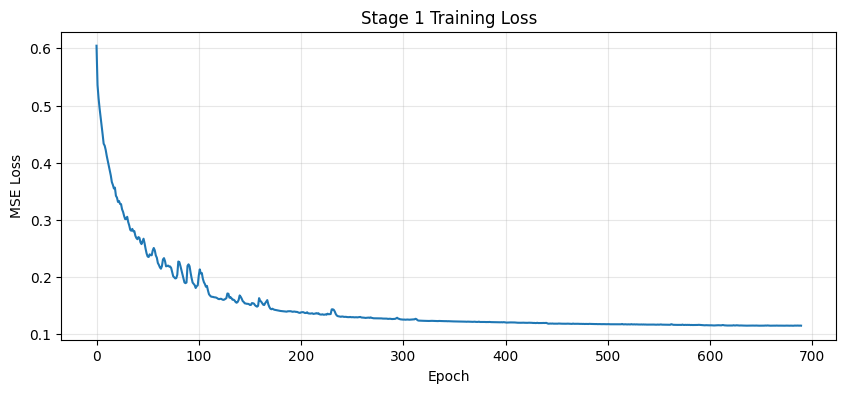

In [20]:
# Plot training process
plt.figure(figsize=(10, 4))
plt.plot(lossgraph_stage1)
plt.title('Stage 1 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.show()

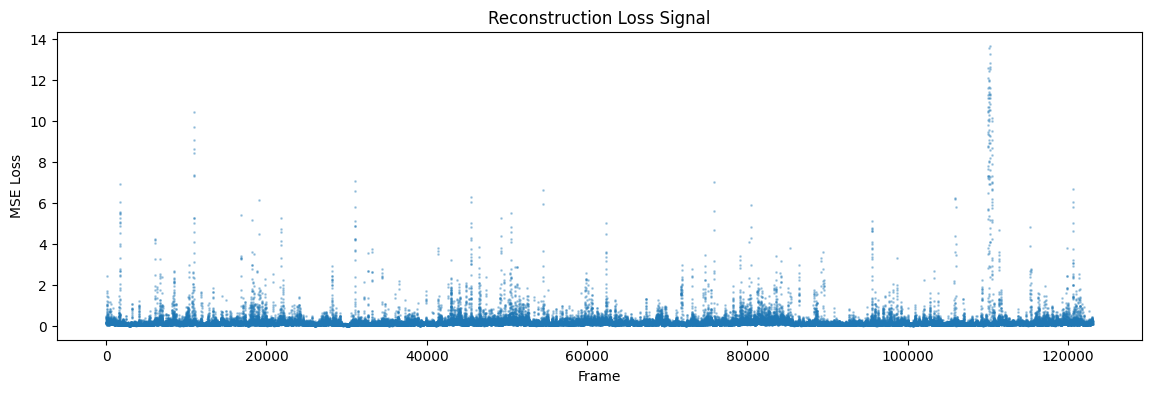

In [21]:
# Plot loss signal
plt.figure(figsize=(14, 4))
plt.plot(positions, losses, '.', markersize=2, alpha=0.3)
plt.title('Reconstruction Loss Signal')
plt.xlabel('Frame')
plt.ylabel('MSE Loss')
plt.show()

Bayesian search for optimal percentile and quantile 

In [22]:
# ── Define search space ──────────────────────────────────────
search_space = [
    Real(*PERCENTILE_RANGE, name='percentile'),
    Real(*QUANTILE_RANGE,   name='quantile'),
    #Real(*LR_RANGE,         name='lr', prior='log-uniform'),
]

search_log = []
best_results = None
best_score = -1
iteration = 0

In [23]:
# ── Objective function ───────────────────────────────────────
@use_named_args(search_space)
def objective(percentile, quantile, lr=LR):
    global iteration, best_score, best_results

    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration}/{MAX_ITER}  |  percentile={percentile:.2f}, quantile={quantile:.4f}, lr={lr:.6f}")
    print(f"{'='*60}")

    # Stage 3: transitions
    transition_frames, smoothed = find_transitions(
        positions, losses, percentile=percentile, fps=25
    )

    # Stage 4: variable windows
    windows, window_segment_labels = create_windows_from_transitions(
        raw_processed, transition_frames,
        min_segment_frames=45, max_segment_frames=60
    )
    
    if len(windows) < 10:
        print(f"  too few windows ({len(windows)}) — skipping")
        return 0.0

    # Stage 4b: retrain on variable windows (with tuned lr)
    model_file_name = "model_stage2_"+str(iteration)+".pth"
    if Path(model_file_name).is_file():
        n_joints  = raw_processed.shape[1]
        joint_dim = raw_processed.shape[2]

        model_stage2 = HierarchicalRAE(latent_dim=LATENT_DIM, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
        state_dict = torch.load(model_file_name, weights_only=True)
        model_stage2.load_state_dict(state_dict)
        print("model_satge2 loaded...")
    else:
        model_stage2, lossgraph_stage2 = train_on_variable_windows(
            raw_processed, windows, epochs=VW_EPOCHS, lr=lr, device=device
        )
        torch.save(model_stage2.state_dict(), os.path.join('./', model_file_name))

    # Stage 5: encode + cluster
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows, quantile=quantile,
        umap_neighbors=15, umap_min_dist=0.1, device=device
    )

    n_clusters = len(np.unique(cluster_labels))

    # ── Compute silhouette score ──────────────────────────────
    # silhouette needs at least 2 clusters and more samples than clusters
    if n_clusters < 2 or n_clusters >= len(latents_2d):
        print(f"  → {n_clusters} clusters — skipping silhouette (invalid cluster count)")
        score = -1.0
    else:
        score = silhouette_score(latents_2d, cluster_labels)

    log_entry = {
        "iteration": iteration,
        "percentile": round(percentile, 2),
        "quantile": round(quantile, 4),
        "lr": round(float(lr), 6),
        "n_clusters": n_clusters,
        "silhouette": round(float(score), 4),
    }
    search_log.append(log_entry)
    print(f"  → {n_clusters} clusters, silhouette={score:.4f}")

    # Track best
    if score > best_score:
        best_score = score
        best_results = {
            'model': model_stage2,
            'model_stage1': model_stage1,
            'latents': latents,
            'latents_2d': latents_2d,
            'cluster_labels': cluster_labels,
            'transition_frames': transition_frames,
            'windows': windows,
            'window_segment_labels': window_segment_labels,
            'losses': losses,
            'positions': positions,
            'lossgraph_stage1': lossgraph_stage1,
            'lossgraph_stage2': lossgraph_stage2,
            'smoothed_losses': smoothed,
            '_percentile': percentile,
            '_quantile': quantile,
            '_lr': lr,
        }
        print(f"  ** NEW BEST (silhouette={score:.4f}) **")

    # Cleanup GPU memory
    del model_stage2, latents, latents_2d, cluster_labels, ms_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # gp_minimize minimizes, so return negative score
    return -score

In [24]:
# ── Run Bayesian optimization ────────────────────────────────
bayes_result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=MAX_ITER,
    n_initial_points=min(MAX_ITER, 5),
    random_state=42,
    verbose=False,
)


ITERATION 1/15  |  percentile=73.90, quantile=0.1367, lr=0.001000
Found 3634 transitions
Mean bout duration: 1.35s
Bout duration looks plausible
Created 1264 variable-length windows from 3635 segments
Window lengths — min: 46, max: 60, mean: 58.1
Retraining on variable-length windows...


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 10/1000 — Loss: 0.434420  patience: 0/30
Epoch 20/1000 — Loss: 0.399239  patience: 0/30
Epoch 30/1000 — Loss: 0.379468  patience: 0/30
Epoch 40/1000 — Loss: 0.370208  patience: 0/30
Epoch 50/1000 — Loss: 0.360024  patience: 0/30
Epoch 60/1000 — Loss: 0.357251  patience: 7/30
Epoch 70/1000 — Loss: 0.349004  patience: 1/30
Epoch 80/1000 — Loss: 0.344752  patience: 2/30
Epoch 90/1000 — Loss: 0.338595  patience: 1/30
Epoch 100/1000 — Loss: 0.336433  patience: 1/30
Epoch 110/1000 — Loss: 0.332550  patience: 7/30
Epoch 120/1000 — Loss: 0.324152  patience: 0/30
Epoch 130/1000 — Loss: 0.319935  patience: 0/30
Epoch 140/1000 — Loss: 0.315477  patience: 3/30
Epoch 150/1000 — Loss: 0.310940  patience: 0/30
Epoch 160/1000 — Loss: 0.308740  patience: 1/30
Epoch 170/1000 — Loss: 0.305992  patience: 4/30
Epoch 180/1000 — Loss: 0.297733  patience: 0/30
Epoch 190/1000 — Loss: 0.298316  patience: 1/30
Epoch 200/1000 — Loss: 0.294355  patience: 0/30
Epoch 210/1000 — Loss: 0.293464  patience: 2/30
E

c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (1264, 2)
Estimated bandwidth: 0.0907
Found 4 clusters
Cluster sizes: [429 305 294 236]
Silhouette score: 0.7665
  → 4 clusters, silhouette=0.3332
  ** NEW BEST (silhouette=0.3332) **

ITERATION 2/15  |  percentile=73.39, quantile=0.2194, lr=0.001000
Found 3694 transitions
Mean bout duration: 1.33s
Bout duration looks plausible
Created 1251 variable-length windows from 3695 segments
Window lengths — min: 46, max: 60, mean: 58.1
Retraining on variable-length windows...


...

UMAP done. Shape: (733, 2)
Estimated bandwidth: 0.1487
Found 3 clusters
Cluster sizes: [363 205 165]
Silhouette score: 0.8139
  → 3 clusters, silhouette=0.4930

ITERATION 15/15  |  percentile=54.11, quantile=0.2313, lr=0.001000
Found 5878 transitions
Mean bout duration: 0.84s
Created 774 variable-length windows from 5879 segments
Window lengths — min: 46, max: 60, mean: 56.9
Retraining on variable-length windows...


c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 10/1000 — Loss: 0.419240  patience: 0/30
Epoch 20/1000 — Loss: 0.384709  patience: 2/30
Epoch 30/1000 — Loss: 0.353179  patience: 1/30
Epoch 40/1000 — Loss: 0.346442  patience: 1/30
Epoch 50/1000 — Loss: 0.323518  patience: 0/30
Epoch 60/1000 — Loss: 0.320514  patience: 6/30
Epoch 70/1000 — Loss: 0.318284  patience: 1/30
Epoch 80/1000 — Loss: 0.303982  patience: 0/30
Epoch 90/1000 — Loss: 0.300158  patience: 1/30
Epoch 100/1000 — Loss: 0.306182  patience: 11/30
Epoch 110/1000 — Loss: 0.303375  patience: 3/30
Epoch 120/1000 — Loss: 0.283822  patience: 0/30
Epoch 130/1000 — Loss: 0.282329  patience: 5/30
Epoch 140/1000 — Loss: 0.271696  patience: 0/30
Epoch 150/1000 — Loss: 0.277536  patience: 10/30
Epoch 160/1000 — Loss: 0.274171  patience: 1/30
Epoch 170/1000 — Loss: 0.272179  patience: 7/30
Epoch 180/1000 — Loss: 0.270810  patience: 9/30
Epoch 190/1000 — Loss: 0.269516  patience: 4/30
Epoch 200/1000 — Loss: 0.267096  patience: 14/30
Epoch 210/1000 — Loss: 0.266365  patience: 24/

c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (774, 2)
Estimated bandwidth: 0.1816
Found 3 clusters
Cluster sizes: [329 254 191]
Silhouette score: 0.8188
  → 3 clusters, silhouette=0.4111


In [25]:
# ── Summary ──────────────────────────────────────────────────
print(f"\n{'='*60}")
print("HYPERPARAMETER SEARCH COMPLETE")
print(f"{'='*60}")
print(f"\nSearch log:")
for entry in search_log:
    marker = " <-- BEST" if entry['silhouette'] == best_score else ""
    print(f"  Iter {entry['iteration']:2d}: percentile={entry['percentile']:5.2f}, "
          f"quantile={entry['quantile']:.4f}, lr={entry['lr']:.6f}  "
          f"→  {entry['n_clusters']} clusters, silhouette={entry['silhouette']:.4f}{marker}")

print(f"\nBest result:")
print(f"  percentile : {best_results['_percentile']:.2f}")
print(f"  quantile   : {best_results['_quantile']:.4f}")
print(f"  lr         : {best_results['_lr']:.6f}")
print(f"  clusters   : {len(np.unique(best_results['cluster_labels']))}")
print(f"  silhouette : {best_score:.4f}")

# Set results to best for downstream cells
results = best_results

# Save the model
torch.save(results['model'].state_dict(), os.path.join('./', "model_stage2.pth"))

with open("lossgraph_stage2.json", "w") as file:
    json.dump(results['lossgraph_stage2'], file)


HYPERPARAMETER SEARCH COMPLETE

Search log:
  Iter  1: percentile=73.90, quantile=0.1367, lr=0.001000  →  4 clusters, silhouette=0.3332
  Iter  2: percentile=73.39, quantile=0.2194, lr=0.001000  →  2 clusters, silhouette=0.4844
  Iter  3: percentile=63.37, quantile=0.1200, lr=0.001000  →  7 clusters, silhouette=0.2186
  Iter  4: percentile=63.78, quantile=0.1667, lr=0.001000  →  5 clusters, silhouette=0.3617
  Iter  5: percentile=54.29, quantile=0.2302, lr=0.001000  →  2 clusters, silhouette=0.7139
  Iter  6: percentile=52.69, quantile=0.2400, lr=0.001000  →  2 clusters, silhouette=0.7629
  Iter  7: percentile=51.51, quantile=0.2477, lr=0.001000  →  3 clusters, silhouette=0.4306
  Iter  8: percentile=80.00, quantile=0.2805, lr=0.001000  →  2 clusters, silhouette=0.5754
  Iter  9: percentile=66.91, quantile=0.3000, lr=0.001000  →  2 clusters, silhouette=0.5842
  Iter 10: percentile=65.34, quantile=0.3000, lr=0.001000  →  4 clusters, silhouette=0.2163
  Iter 11: percentile=53.03, quanti

Plot cluster 

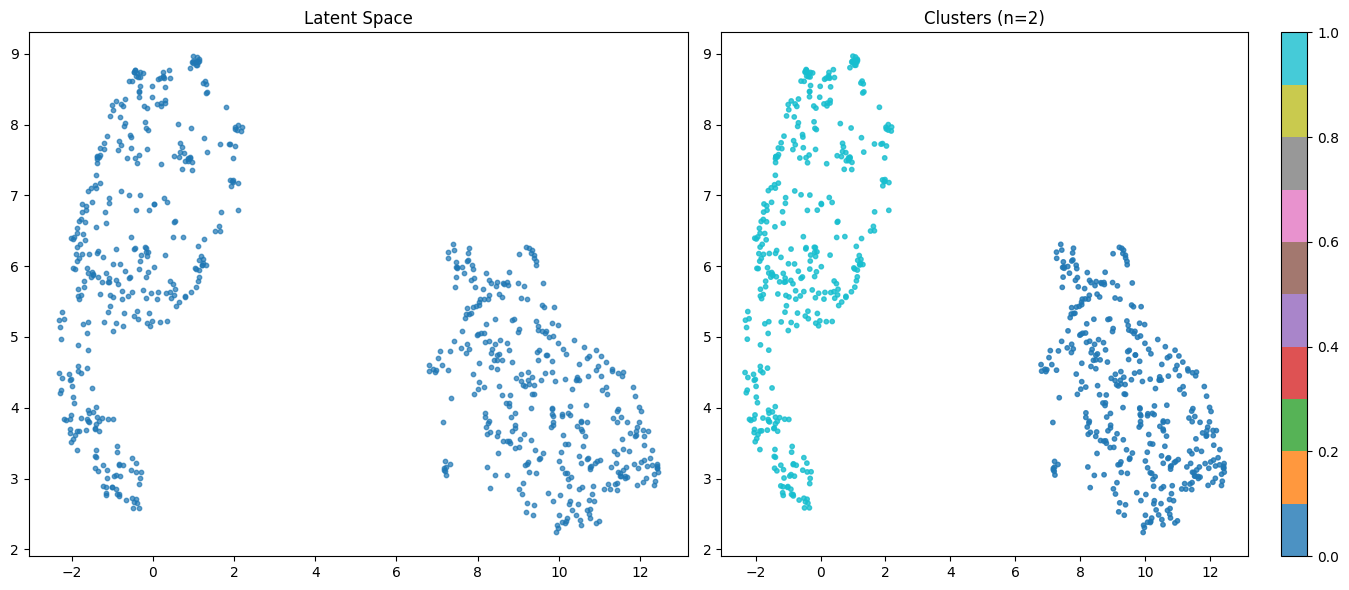

In [26]:
latents_2d     = results['latents_2d']
cluster_labels = results['cluster_labels']
n_clusters     = len(np.unique(cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(latents_2d[:, 0], latents_2d[:, 1], s=10, alpha=0.7)
axes[0].set_title('Latent Space')
sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                     c=cluster_labels, cmap='tab10', s=10, alpha=0.8)
axes[1].set_title(f'Clusters (n={n_clusters})')
plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.show()

Reconstruct window

Window starts: 737 vs windows: 737
PD windows: 497, Control windows: 240


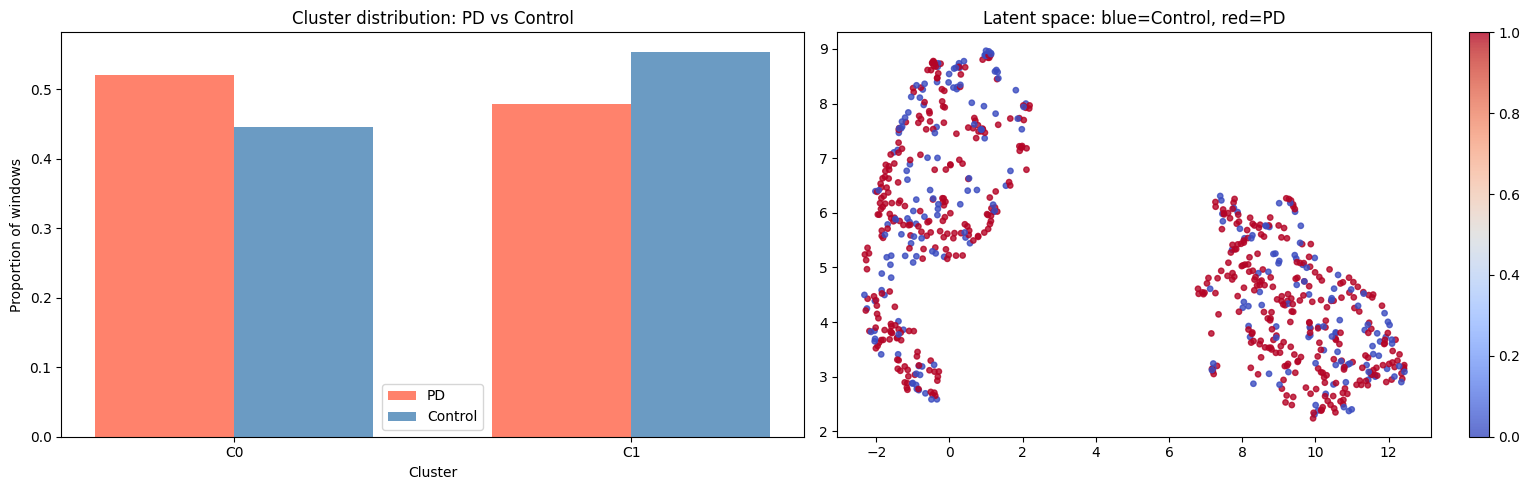


Cluster          PD    Control   Ratio PD/C
  C0          0.521      0.446         1.17
  C1          0.479      0.554         0.86


In [27]:
min_segment_frames = 45
max_segment_frames = 60
boundaries = np.unique(
    np.concatenate([[0], results['transition_frames'], [len(raw_processed)]])
).astype(int)

starts = []
for seg_idx in range(len(boundaries) - 1):
    seg_start = boundaries[seg_idx]
    seg_end   = boundaries[seg_idx + 1]
    seg_len   = seg_end - seg_start
    if seg_len < min_segment_frames: continue
    for chunk_start in range(0, seg_len, max_segment_frames):
        abs_start = seg_start + chunk_start
        abs_end   = min(abs_start + max_segment_frames, seg_end)
        if (abs_end - abs_start) < min_segment_frames: continue
        starts.append(abs_start)
starts = np.array(starts)
print(f"Window starts: {len(starts)} vs windows: {len(results['windows'])}")

# assign PD/C label to each window
window_group_labels = []
for win_idx in range(len(results['windows'])):
    abs_start    = starts[win_idx]
    abs_end      = abs_start + len(results['windows'][win_idx])
    frame_labels = group_labels_arr[abs_start:abs_end]
    majority     = int(np.round(frame_labels.mean()))
    window_group_labels.append(majority)

window_group_labels = np.array(window_group_labels)
pd_mask = window_group_labels == 1
c_mask  = window_group_labels == 0
print(f"PD windows: {pd_mask.sum()}, Control windows: {c_mask.sum()}")

cluster_labels = results['cluster_labels']
n_clusters     = len(np.unique(cluster_labels))
pd_counts = np.array([(cluster_labels[pd_mask] == c).sum() for c in range(n_clusters)])
c_counts  = np.array([(cluster_labels[c_mask]  == c).sum() for c in range(n_clusters)])
pd_props  = pd_counts / pd_counts.sum() if pd_counts.sum() > 0 else pd_counts
c_props   = c_counts  / c_counts.sum()  if c_counts.sum()  > 0 else c_counts

x = np.arange(n_clusters)
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(x - w/2, pd_props, w, label='PD',      color='tomato',    alpha=0.8)
axes[0].bar(x + w/2, c_props,  w, label='Control', color='steelblue', alpha=0.8)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Proportion of windows')
axes[0].set_title('Cluster distribution: PD vs Control')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'C{i}' for i in range(n_clusters)])
axes[0].legend()

sc = axes[1].scatter(latents_2d[:, 0], latents_2d[:, 1],
                     c=window_group_labels, cmap='coolwarm',
                     s=15, alpha=0.8, vmin=0, vmax=1)
axes[1].set_title('Latent space: blue=Control, red=PD')
plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"\n{'Cluster':<10} {'PD':>8} {'Control':>10} {'Ratio PD/C':>12}")
for i in range(n_clusters):
    ratio = pd_props[i] / c_props[i] if c_props[i] > 0 else float('inf')
    print(f"  C{i:<7} {pd_props[i]:>8.3f} {c_props[i]:>10.3f} {ratio:>12.2f}")

In [28]:
with open("best_results.pkl", "wb") as file:
    pickle.dump(results, file)

Load best_results from local disk

In [ ]:
with open("best_results.pkl", "rb") as file:
    results = pickle.load(file)